In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sklearn.inspection import permutation_importance
from lifelines import CoxPHFitter

df = pd.read_csv("../data/processed/tcga_features.csv")
print(f"Loaded {len(df):,} patients")

Loaded 2,662 patients


In [2]:
def build_xy(df_cancer, min_mut_freq=5):
    gene_cols = [c for c in df_cancer.columns if c.startswith("mut_")]
    freq_genes = [g for g in gene_cols if df_cancer[g].sum() >= min_mut_freq]
    features = ["AGE", "total_mutations"] + freq_genes
    sub = df_cancer[features + ["OS_MONTHS", "event"]].dropna()
    X = sub[features].copy()
    y = Surv.from_dataframe("event", "OS_MONTHS", sub.astype({"event": bool}))
    return X, y, features

In [3]:
MODEL_DIR = Path("../models")
importance_results = {}

for cancer in ["HNSC", "LUAD", "BRCA", "COAD"]:
    saved = joblib.load(MODEL_DIR / f"{cancer}_best_survival_model.joblib")
    if saved["model_type"] != "Random Survival Forest":
        print(f"{cancer}: skipping (best model was {saved['model_type']}, not RSF)")
        continue

    rsf = saved["model"]
    features = saved["features"]

    sub = df[df["cancer_type"] == cancer]
    X, y, _ = build_xy(sub)
    X = X[features]  # ensure column order matches

    # Use a custom scoring function (RSF has its own score method)
    def score(estimator, X, y):
        return concordance_index_censored(y["event"], y["OS_MONTHS"],
                                          estimator.predict(X))[0]

    print(f"\n=== {cancer} — running permutation importance (10 repeats) ===")
    pi = permutation_importance(rsf, X, y, scoring=score,
                                 n_repeats=10, random_state=42, n_jobs=-1)
    imp_df = pd.DataFrame({
        "feature": features,
        "importance_mean": pi.importances_mean,
        "importance_std":  pi.importances_std,
    }).sort_values("importance_mean", ascending=False)
    importance_results[cancer] = imp_df
    print(imp_df.head(10).round(4))


=== HNSC — running permutation importance (10 repeats) ===
            feature  importance_mean  importance_std
0               AGE           0.0756          0.0152
26         mut_TP53           0.0396          0.0115
19         mut_NSD1           0.0254          0.0074
1   total_mutations           0.0247          0.0110
7        mut_CDKN2A           0.0085          0.0025
18       mut_NOTCH1           0.0076          0.0025
10         mut_FAT1           0.0070          0.0020
14        mut_KMT2C           0.0062          0.0023
20       mut_PIK3CA           0.0058          0.0019
13         mut_HRAS           0.0055          0.0042

=== LUAD — running permutation importance (10 repeats) ===
            feature  importance_mean  importance_std
0               AGE           0.0627          0.0109
1   total_mutations           0.0440          0.0130
25        mut_STK11           0.0317          0.0127
9          mut_EGFR           0.0213          0.0040
26         mut_TP53           0.

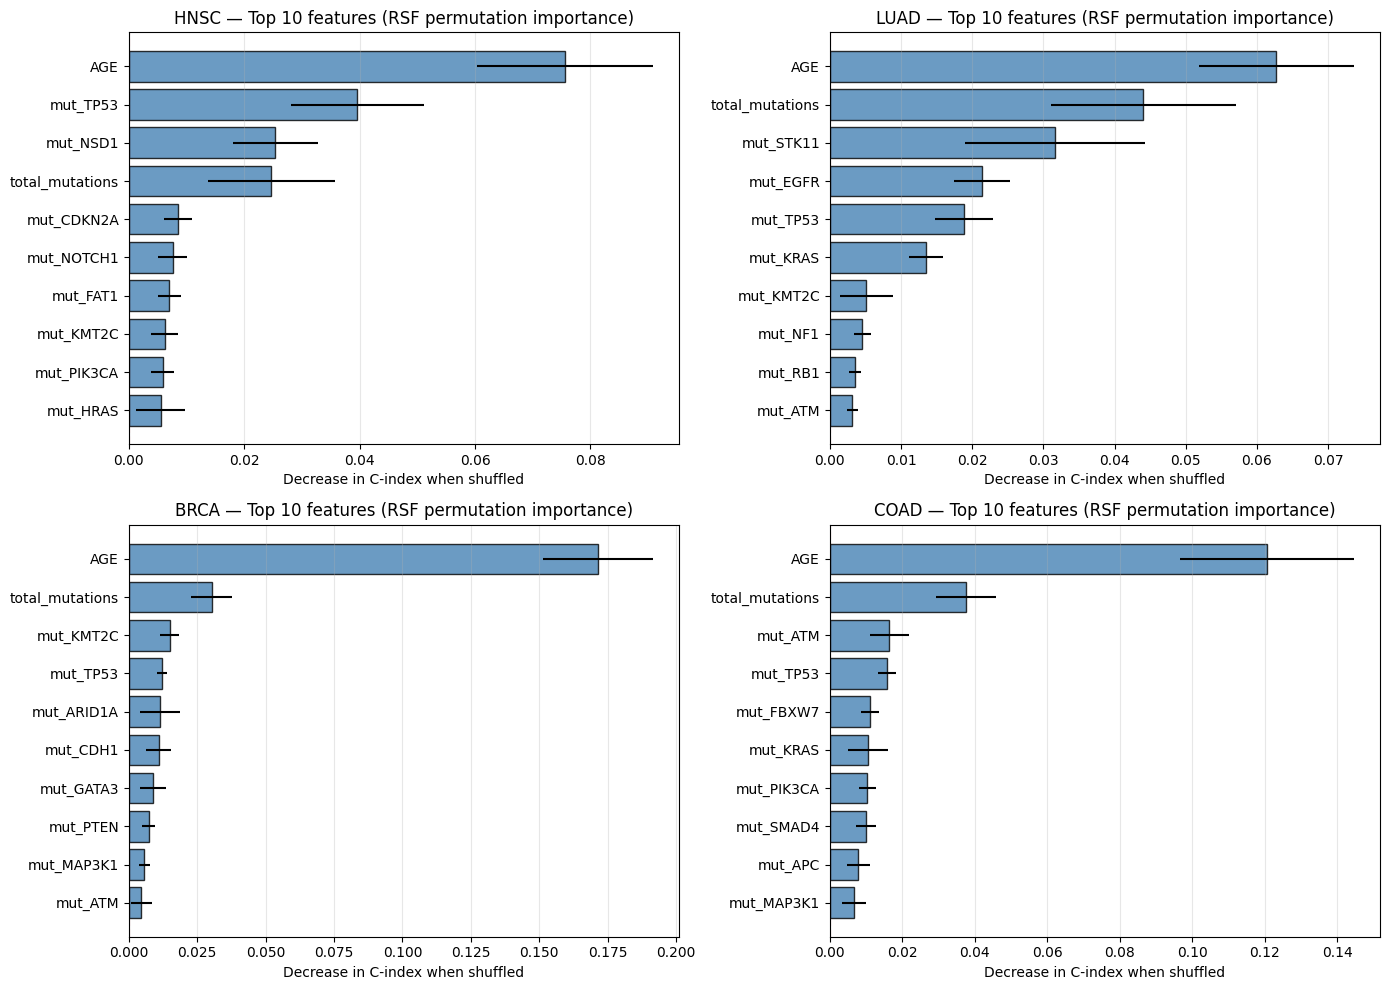

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, cancer in enumerate(["HNSC", "LUAD", "BRCA", "COAD"]):
    if cancer not in importance_results:
        continue
    imp = importance_results[cancer].head(10).sort_values("importance_mean")
    axes[i].barh(imp["feature"], imp["importance_mean"],
                 xerr=imp["importance_std"], color="steelblue",
                 edgecolor="black", alpha=0.8)
    axes[i].set_title(f"{cancer} — Top 10 features (RSF permutation importance)")
    axes[i].set_xlabel("Decrease in C-index when shuffled")
    axes[i].grid(axis="x", alpha=0.3)
    axes[i].axvline(0, color="red", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [5]:
def cox_hazard_ratios(df_cancer, features):
    train = df_cancer[features + ["OS_MONTHS", "event"]].dropna()
    cph = CoxPHFitter(penalizer=0.05)
    cph.fit(train, duration_col="OS_MONTHS", event_col="event")
    s = cph.summary
    return s[["exp(coef)", "p"]].rename(columns={"exp(coef)": "HR"})

biomarker_summary = []
for cancer, imp_df in importance_results.items():
    sub = df[df["cancer_type"] == cancer]
    X, y, features = build_xy(sub)
    try:
        hr = cox_hazard_ratios(sub, features)
    except Exception as e:
        print(f"{cancer}: HR failed - {e}")
        continue

    # Join importance + HR
    merged = imp_df.merge(hr, left_on="feature", right_index=True, how="left")
    merged["cancer"] = cancer
    merged["direction"] = np.where(merged["HR"] > 1, "Risk", "Protective")
    biomarker_summary.append(merged.head(10))

biomarker_summary = pd.concat(biomarker_summary, ignore_index=True)
biomarker_summary[["cancer", "feature", "importance_mean", "HR", "p", "direction"]].round(3)

,cancer,feature,importance_mean,HR,p,direction
0,HNSC,AGE,0.076,1.014,0.022,Risk
1,HNSC,mut_TP53,0.040,1.558,0.013,Risk
2,HNSC,mut_NSD1,0.025,0.638,0.068,Protective
3,HNSC,total_mutations,0.025,1.051,0.594,Risk
4,HNSC,mut_CDKN2A,0.009,0.765,0.158,Protective
5,HNSC,mut_NOTCH1,0.008,1.176,0.404,Risk
6,HNSC,mut_FAT1,0.007,0.879,0.488,Protective
7,HNSC,mut_KMT2C,0.006,0.837,0.510,Protective
8,HNSC,mut_PIK3CA,0.006,1.053,0.786,Risk
9,HNSC,mut_HRAS,0.006,0.658,0.210,Protective


In [6]:
out = Path("../data/processed")
biomarker_summary.to_csv(out / "biomarker_summary.csv", index=False)

# Save per-cancer importance dataframes too
for cancer, imp_df in importance_results.items():
    imp_df.to_csv(out / f"{cancer}_feature_importance.csv", index=False)

print(f"Saved biomarker tables to {out.resolve()}")
print(f"\nTop biomarker per cancer:")
for cancer, imp_df in importance_results.items():
    top = imp_df.iloc[0]
    print(f"  {cancer}: {top['feature']} (importance={top['importance_mean']:.4f})")

Saved biomarker tables to /Users/ammulakshmim.s/Documents/GitHub/tcga-survival-genomics/data/processed

Top biomarker per cancer:
  HNSC: AGE (importance=0.0756)
  LUAD: AGE (importance=0.0627)
  BRCA: AGE (importance=0.1715)
  COAD: AGE (importance=0.1206)
